In [18]:
from pathlib import Path

model_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml")
data_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data")

In [19]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [20]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [21]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


In [22]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [23]:
import ipywidgets as widgets
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Detect available models
def get_available_models(model_folder):
    """Detect all PyTorch model files in the folder."""
    models = []
    if model_folder.exists():
        models = sorted([f.name for f in model_folder.glob("*") if f.is_file()])
    return models

# Detect available data files
def get_available_data(data_folder):
    """Detect Y data files with shape (N, 2) for ACC and RT."""
    data_files = []
    if data_folder.exists():
        for f in sorted(data_folder.glob("Y_*.npy")):
            try:
                data = np.load(f)
                if data.ndim == 2 and data.shape[1] == 2:
                    data_files.append(f.name)
            except Exception:
                pass
    return data_files

def get_available_x_data(data_folder):
    """Detect X data files."""
    x_files = []
    if data_folder.exists():
        x_files = sorted([f.name for f in data_folder.glob("X_*.npy") if f.is_file()])
    return x_files

available_models = get_available_models(model_folder)
available_data = get_available_data(data_folder)
available_x = get_available_x_data(data_folder)

print(f"Found {len(available_models)} models: {available_models}")
print(f"Found {len(available_data)} Y data files: {available_data}")
print(f"Found {len(available_x)} X data files: {available_x}")

Found 2 models: ['evoked_model_500_1771166304.2371216.pkl', 'snr_model_500_1771167871.4968765.pkl']
Found 2 Y data files: ['Y_evoked_500_1771166884.1613965.npy', 'Y_snr_500_1771167865.7485447.npy']
Found 2 X data files: ['X_evoked_500_1771166523.7729328.npy', 'X_snr_500_1771167863.7117176.npy']


In [24]:
selected_x = available_x[0] if available_x else None
x_path = data_folder / selected_x
X = np.load(x_path)

In [25]:
selected_y = available_data[0] if available_data else None
y_path = data_folder / selected_y
y = np.load(y_path)

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Build groups and keep aligned lengths to avoid indexing errors
groups = np.asarray(selected_subjects)
n = min(len(X), len(y), len(groups))
X = X[:n]
y = y[:n]
groups = groups[:n]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Unique subjects:", len(np.unique(groups)))

# Subject-wise holdout split (prevents leakage across same subject)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train subjects:", len(np.unique(groups_train)), "Test subjects:", len(np.unique(groups[test_idx])))

X shape: (500, 2613)
y shape: (500, 2)
groups shape: (500,)
Unique subjects: 500
Train shape: (400, 2613) Test shape: (100, 2613)
Train subjects: 400 Test subjects: 100


In [27]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", MultiOutputRegressor(SVR(kernel="rbf"))),
])

Best params: {'model__estimator__C': np.float64(0.1), 'model__estimator__epsilon': 0.01, 'model__estimator__gamma': 'scale', 'pca__n_components': 0.9}
SVR multi-output: ACC(corr=-0.1013, mae=15.8174) | RT(corr=0.0115, mae=0.1784)


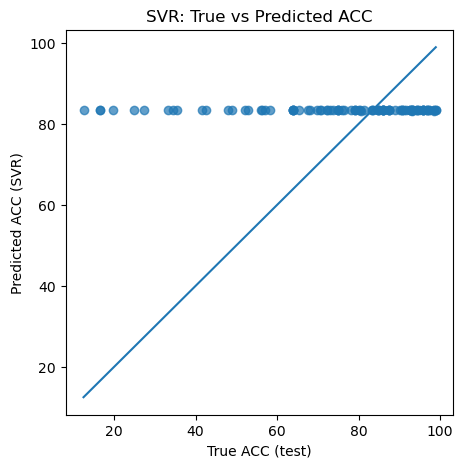

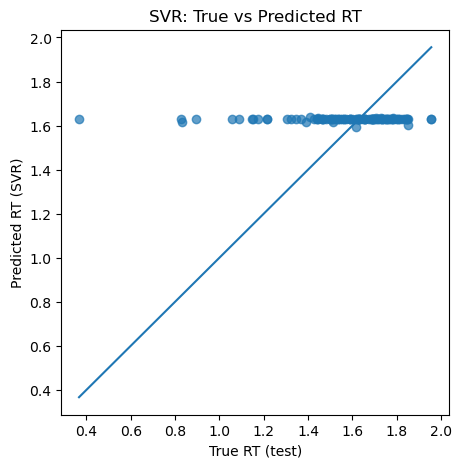

In [28]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", MultiOutputRegressor(SVR(kernel="rbf"))),
])

param_grid = {
    "pca__n_components": [10, 20, 40, 80, 120, 0.90, 0.95, 0.98],
    "model__estimator__C": np.logspace(-1, 3, 10),
    "model__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    "model__estimator__gamma": ["scale", "auto"],
}

inner_cv = GroupKFold(n_splits=4)

search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)
search.fit(X_train, y_train, groups=groups_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)


def summarize(name, y_true, y_hat):
    """Print ACC/RT correlation and MAE."""
    acc_corr_v = np.corrcoef(y_true[:, 0], y_hat[:, 0])[0, 1]
    rt_corr_v = np.corrcoef(y_true[:, 1], y_hat[:, 1])[0, 1]
    acc_mae_v = mean_absolute_error(y_true[:, 0], y_hat[:, 0])
    rt_mae_v = mean_absolute_error(y_true[:, 1], y_hat[:, 1])

    print(
        f"{name}: "
        f"ACC(corr={acc_corr_v:.4f}, mae={acc_mae_v:.4f}) | "
        f"RT(corr={rt_corr_v:.4f}, mae={rt_mae_v:.4f})"
    )


print("Best params:", search.best_params_)
summarize("SVR multi-output", y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.7)
acc_lo = min(y_test[:, 0].min(), y_pred[:, 0].min())
acc_hi = max(y_test[:, 0].max(), y_pred[:, 0].max())
plt.plot([acc_lo, acc_hi], [acc_lo, acc_hi])
plt.xlabel("True ACC (test)")
plt.ylabel("Predicted ACC (SVR)")
plt.title("SVR: True vs Predicted ACC")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(y_test[:, 1], y_pred[:, 1], alpha=0.7)
rt_lo = min(y_test[:, 1].min(), y_pred[:, 1].min())
rt_hi = max(y_test[:, 1].max(), y_pred[:, 1].max())
plt.plot([rt_lo, rt_hi], [rt_lo, rt_hi])
plt.xlabel("True RT (test)")
plt.ylabel("Predicted RT (SVR)")
plt.title("SVR: True vs Predicted RT")
plt.show()

In [29]:
print("\nPipeline Steps:")
for name, step in best_model.named_steps.items():
    print(f"\n{name}:")
    print(step)



Pipeline Steps:

scaler:
StandardScaler()

pca:
PCA(n_components=0.9)

model:
MultiOutputRegressor(estimator=SVR(C=np.float64(0.1), epsilon=0.01))


In [30]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Evaluate on test set
mae_acc = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
mae_rt  = mean_absolute_error(y_test[:, 1], y_pred[:, 1])

r2_acc = r2_score(y_test[:, 0], y_pred[:, 0])
r2_rt  = r2_score(y_test[:, 1], y_pred[:, 1])

corr_acc = np.corrcoef(y_test[:, 0], y_pred[:, 0])[0, 1]
corr_rt  = np.corrcoef(y_test[:, 1], y_pred[:, 1])[0, 1]

# Create summary table
summary = pd.DataFrame({
    "Target": ["ACC", "RT"],
    "MAE": [mae_acc, mae_rt],
    "R2": [r2_acc, r2_rt],
    "Correlation": [corr_acc, corr_rt],
})

print("Best Parameters:")
print(search.best_params_)

print("\nModel Performance Summary:")
print(summary.round(4))


Best Parameters:
{'model__estimator__C': np.float64(0.1), 'model__estimator__epsilon': 0.01, 'model__estimator__gamma': 'scale', 'pca__n_components': 0.9}

Model Performance Summary:
  Target      MAE      R2  Correlation
0    ACC  15.8174 -0.1143      -0.1013
1     RT   0.1784 -0.0604       0.0115


In [31]:
baseline_acc = np.mean(y_train[:, 0])
baseline_rt  = np.mean(y_train[:, 1])

baseline_mae_acc = mean_absolute_error(y_test[:, 0],
                                       np.full_like(y_test[:, 0], baseline_acc))

baseline_mae_rt  = mean_absolute_error(y_test[:, 1],
                                       np.full_like(y_test[:, 1], baseline_rt))

print("Baseline MAE (ACC):", round(baseline_mae_acc, 4))
print("Baseline MAE (RT):", round(baseline_mae_rt, 4))

Baseline MAE (ACC): 16.8694
Baseline MAE (RT): 0.1823
